In [2]:
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [38]:
dataroot = "/Users/haoming/Desktop/ML Basics/football_player_generator/football_images"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

latent_dim = 128

num_epochs = 50

# Learning rate for optimizers
lr = 0.001

beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 0

Min value of the first image: 0.045900583267211914
Max value of the first image: 0.9683719277381897


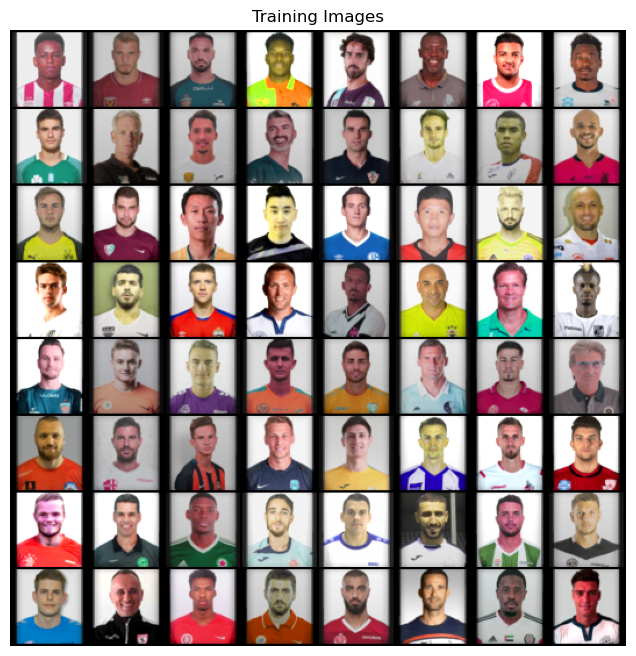

In [4]:
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.RandomHorizontalFlip(),
                               transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                           ]))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
images, labels = next(iter(dataloader))

# Check the range of values in the first image in the batch
print(f"Min value of the first image: {images[0].min()}")
print(f"Max value of the first image: {images[0].max()}")
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [39]:
class convolution_vae(nn.Module):
    def __init__(self, ngpu):
        super(convolution_vae, self).__init__()
        self.ngpu = ngpu
        self.encoder = nn.Sequential(
            nn.Conv2d(nc, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )
        # Modify the size of the latent space here (set to 128)
        self.fc_mu = nn.Linear(128 * 8 * 8, 128)  # Latent space of size 128
        self.fc_logvar = nn.Linear(128 * 8 * 8, 128)  # Latent space of size 128
        
        # Update the fc_decode layer to accept the new latent space size
        self.fc_decode = nn.Linear(128, 128 * 8 * 8)  # Latent space of size 128

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, nc, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )
        
    def encode(self, x):
        x = self.encoder(x)
        x = x.view(-1, 128 * 8 * 8)  # Flatten to [batch_size, 8192] 
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        z = self.fc_decode(z)  # Use the new latent size
        z = z.view(-1, 128, 8, 8)  # Reshape to match the decoder input
        z = self.decoder(z)
        return z

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

model = convolution_vae(ngpu).to(device)




In [40]:
print(model)

convolution_vae(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [41]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x.view(-1, 64 * 64 * 3), x.view(-1, 64 * 64 * 3), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

Epoch 0, Batch 0, Loss: 1179405.0
Epoch 0, Loss: 132011.8125
Epoch 1, Batch 0, Loss: 771041.25
Epoch 1, Loss: 146254.5625
Epoch 2, Batch 0, Loss: 756189.25
Epoch 2, Loss: 127027.8984375
Epoch 3, Batch 0, Loss: 750423.625
Epoch 3, Loss: 134084.609375
Epoch 4, Batch 0, Loss: 723047.875
Epoch 4, Loss: 135532.9375
Epoch 5, Batch 0, Loss: 725317.9375
Epoch 5, Loss: 125556.234375
Epoch 6, Batch 0, Loss: 728753.0625
Epoch 6, Loss: 127524.453125
Epoch 7, Batch 0, Loss: 721661.5625
Epoch 7, Loss: 127315.8359375
Epoch 8, Batch 0, Loss: 709728.5625
Epoch 8, Loss: 122454.6328125
Epoch 9, Batch 0, Loss: 711079.8125
Epoch 9, Loss: 122971.46875
Epoch 10, Batch 0, Loss: 719395.8125
Epoch 10, Loss: 132835.171875
Epoch 11, Batch 0, Loss: 700686.4375
Epoch 11, Loss: 128915.1328125
Epoch 12, Batch 0, Loss: 708749.875
Epoch 12, Loss: 139330.6875
Epoch 13, Batch 0, Loss: 745234.375
Epoch 13, Loss: 127427.859375
Epoch 14, Batch 0, Loss: 700486.8125
Epoch 14, Loss: 117972.015625
Epoch 15, Batch 0, Loss: 69250

Text(0, 0.5, 'Loss')

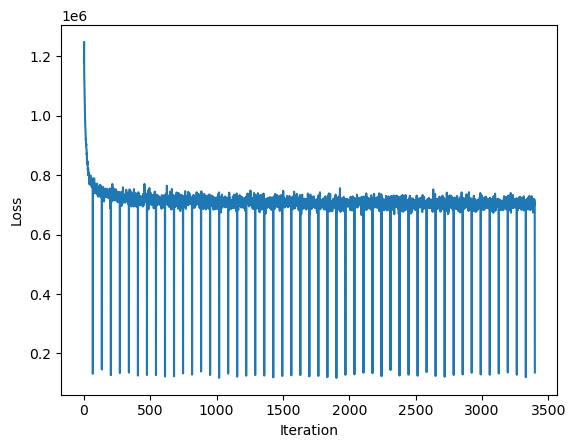

In [42]:
loss = []
for epoch in range(num_epochs):
    torch.save(model.state_dict(), "checkpoint.pth")
    model.train()
    for i, data in enumerate(dataloader):
        data = data[0].to(device)
        """Normalize data to 0 to 1"""
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss_value = loss_function(recon_batch, data, mu, logvar)
        loss_value.backward()
        optimizer.step()
        loss.append(loss_value.item())
        if i % 100 == 0:
            print(f'Epoch {epoch}, Batch {i}, Loss: {loss_value.item()}')
    print(f'Epoch {epoch}, Loss: {loss_value.item()}')
    torch.save(model.state_dict(), "checkpoint.pth")
plt.plot(loss)
plt.xlabel('Iteration')
plt.ylabel('Loss')


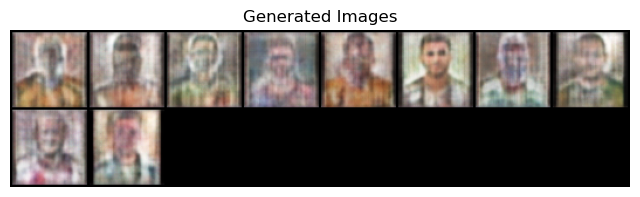

In [37]:
model.eval()
with torch.no_grad():
    latent_vectors = torch.randn(10, 8192).to(device)  # Replace `latent_dim` with your latent space size
    generated_images = model.decode(latent_vectors).cpu() 
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(np.transpose(vutils.make_grid(generated_images, padding=2, normalize=True), (1, 2, 0)))
plt.show()

In [14]:
print(model.fc_decode)

Linear(in_features=8192, out_features=8192, bias=True)
